# Module 04: Seaborn for Machine Learning
## Notebook 03: Correlation Heatmaps and Hierarchical Clustermaps

Multicollinearity—where two or more input features are strongly linearly correlated—inflates the variance of regression coefficients, causes unstable feature attributions, and slows model training. Seaborn's matrix plots are the premier diagnostic tool to detect redundancy.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Compute Pearson and Spearman correlation matrices using Pandas `.corr()`.
2. Construct annotated correlation heatmaps with divergent colormaps.
3. Apply upper-triangle masking using `np.triu()` to eliminate visual redundancy.
4. Interpret correlation values to identify candidate features for pruning or PCA.
5. Build **Hierarchical Clustermaps** with dendrograms to identify latent groupings.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Seaborn loaded!")

Seaborn loaded!


### 1. Computing Correlation Matrices

- **Pearson Correlation ($r \in [-1, 1]$)**: Measures linear relationships. Assumes continuous, approximately normal variables.
- **Spearman Rank Correlation ($\rho \in [-1, 1]$)**: Measures monotonic relationships. Robust to non-linearities and extreme outliers!

In [2]:
# Generate realistic credit risk feature set
rng = np.random.default_rng(42)
N = 250

income = rng.normal(65000, 15000, N)
credit_limit = income * 0.4 + rng.normal(0, 3000, N)  # highly correlated with income
debt = credit_limit * rng.uniform(0.1, 0.8, N)
credit_score = 750 - (debt / credit_limit) * 150 + rng.normal(0, 20, N)
age = rng.integers(22, 65, N)
missed_payments = np.clip((800 - credit_score) / 40 + rng.normal(0, 1, N), 0, 10).astype(int)

df_credit = pd.DataFrame({
    'Income': income,
    'Credit_Limit': credit_limit,
    'Total_Debt': debt,
    'Credit_Score': credit_score,
    'Age': age,
    'Missed_Payments': missed_payments
})

corr_matrix = df_credit.corr(method='pearson')
print("Pearson Correlation Matrix:\n", corr_matrix.round(2))

Pearson Correlation Matrix:
                  Income  Credit_Limit  Total_Debt  Credit_Score   Age  \
Income             1.00          0.89        0.40          0.05 -0.11   
Credit_Limit       0.89          1.00        0.46          0.03 -0.10   
Total_Debt         0.40          0.46        1.00         -0.69 -0.05   
Credit_Score       0.05          0.03       -0.69          1.00  0.00   
Age               -0.11         -0.10       -0.05          0.00  1.00   
Missed_Payments   -0.09         -0.06        0.38         -0.58 -0.02   

                 Missed_Payments  
Income                     -0.09  
Credit_Limit               -0.06  
Total_Debt                  0.38  
Credit_Score               -0.58  
Age                        -0.02  
Missed_Payments             1.00  


---
### 2. Building Masked Correlation Heatmaps

In a symmetric $D \times D$ correlation matrix:
- The diagonal is always 1.0 (self-correlation).
- The upper triangle is an exact mirror of the lower triangle.
Using `np.triu()` creates a boolean mask that hides the upper triangle, doubling readability!

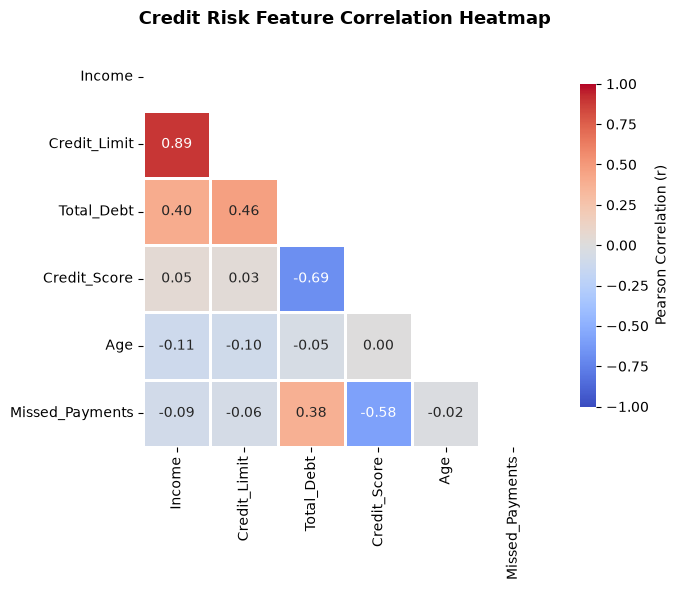

In [3]:
# Generate boolean mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    square=True,
    linewidths=1.0,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"},
    ax=ax
)

ax.set_title("Credit Risk Feature Correlation Heatmap", fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

---
### 3. Hierarchical Clustermaps: `sns.clustermap()`

While a standard heatmap displays features in their arbitrary dataset column order, `sns.clustermap()` applies **Agglomerative Hierarchical Clustering**:
- Computes pairwise distances between features.
- Reorders rows and columns so that correlated features are placed adjacent to one another.
- Displays a **Dendrogram tree** depicting the cluster hierarchy!

In [7]:
# Clustermap of feature correlations
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1.0,
    vmax=1.0,
    figsize=(7.5, 7.5),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.04, 0.15)
)

g.fig.suptitle("Hierarchically Clustered Feature Dendrogram", fontsize=13, fontweight='bold', y=1.02)
plt.show()

RuntimeError: clustermap requires scipy to be available

### Summary & Next Steps
In this notebook, you mastered:
- Computing Pearson vs Spearman correlation matrices.
- Eliminating visual clutter with upper-triangle masked heatmaps.
- Hierarchical feature clustering with `sns.clustermap()`.
- Programmatically identifying collinear feature pairs for dimensionality reduction.

**Next Notebook:** `04_multi_plot_grids_and_eda_workflow.ipynb` — Pair plots, Facet grids, and end-to-end Exploratory Data Analysis (EDA) pipelines.